In [499]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math

pd.set_option('display.max_columns', None)

In [500]:
VAR = 'wz'
REF_VAR = 'kongsberg_' + VAR
RAW_VAR = 'measure_'   + VAR
VIEW_LIMITS = (0.5, 0.7)

# DADOS

In [501]:
df = pd.read_csv('files/DataBase.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,time,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
0,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.3497,0.000000,105000000.0,-0.02016,0.15330,-2041,995881,10237,0,414,-42019,542,16331,0,44195,0,0,-34458,0.0
1,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.3400,0.098466,205000000.0,-0.02187,0.12410,-2049,996410,9993,0,404,16833,542,6044,0,-8122,0,0,-35491,0.0
2,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.3360,0.191033,305000000.0,-0.02364,0.10510,-2069,997799,11574,0,405,23077,547,-16278,0,-8988,0,0,-37327,0.0
3,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.3610,0.295896,405000000.0,-0.02549,0.10260,-2080,996266,9130,0,411,9916,544,24291,0,-22547,0,0,-38009,0.0
4,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.3827,0.389251,505000000.0,-0.02747,0.10320,-2081,994063,8906,0,414,-22535,533,-2136,0,-22888,0,0,-37566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347,0.6862,-9.772,0.6997,-0.19410,-0.04343,-0.099752,12.238379,88.980346,-19.555050,0.099809,0.147078,0.5107,134.696582,805000000.0,10.00000,-0.08408,1766,949448,7663,0,3067,-324366,-1214,-136565,0,152352,0,0,-4162,0.0
1348,0.6862,-9.780,0.6997,-0.19400,-0.04362,-0.101127,12.221190,88.980346,-19.566509,0.298339,0.142896,0.4834,134.791253,905000000.0,10.00000,-0.07341,2001,1035621,960,0,2881,-169033,-1032,-405625,0,222068,0,0,34201,0.0
1349,0.6860,-9.777,0.6998,-0.19410,-0.04386,-0.338160,12.209731,89.037641,-19.589427,0.035753,0.159855,0.4994,134.904581,5000000.0,10.00000,-0.07292,2368,1002344,-1721,0,2761,-82392,-957,-204711,0,34917,0,0,50603,0.0
1350,0.6859,-9.777,0.6999,-0.19430,-0.04415,-0.375058,12.204001,89.037641,-19.629534,-0.030808,0.215432,0.4787,134.999204,105000000.0,10.00000,-0.07352,2554,995492,3564,0,2718,-8750,-926,-126821,0,3074,0,0,46687,0.0


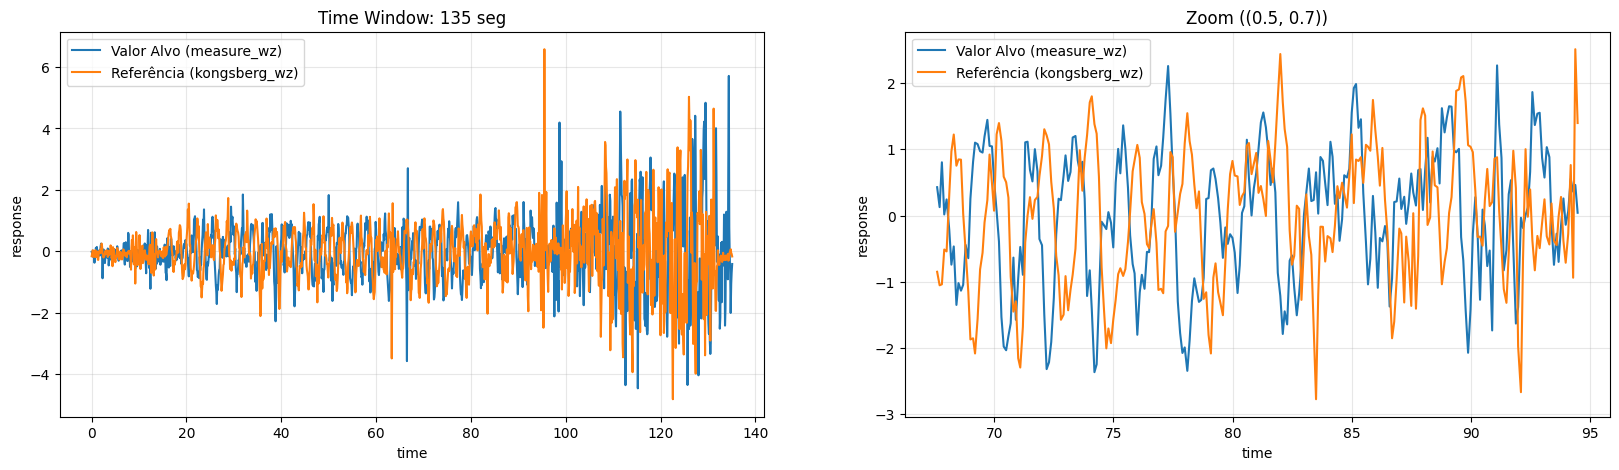

In [502]:
def normalize(array):
    return (array - np.mean(array)) / np.std(array)


VIEW_TIME = (df.time.values[-1]*VIEW_LIMITS[0], df.time.values[-1]*VIEW_LIMITS[1])
target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, normalize(df[RAW_VAR]), label=f'Valor Alvo ({RAW_VAR})')
plt.plot(df.time, normalize(df[REF_VAR]), label=f'Referência ({REF_VAR})')
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.title(f'Time Window: {df.time.max():.0f} seg')

plt.subplot(1, 2, 2)
plt.plot(target.time, normalize(target[RAW_VAR]), label=f'Valor Alvo ({RAW_VAR})')
plt.plot(target.time, normalize(target[REF_VAR]), label=f'Referência ({REF_VAR})')
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.title(f'Zoom ({VIEW_LIMITS})')
plt.show()

# DEFASAGEM

In [503]:
class Phaser:
    def __init__(self, target, reference):
        self.target    = target
        self.reference = reference

    def get(self, df):
        x_norm = normalize(df[self.target])
        y_norm = normalize(df[self.reference])
        
        correlation = np.correlate(y_norm, x_norm, mode='full')
        lags = np.arange(-len(df) + 1, len(df))
        lag  = lags[np.argmax(correlation)]
        return lag

    def set(self, df, lag):
        if lag == 0:
            return df

        df.loc[:, self.target] = df[self.target].shift(lag)
        df = df.dropna().reset_index(drop=True)
        return df


target = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]
phaser = Phaser(RAW_VAR, REF_VAR)
lag    = phaser.get(target)
print(lag, 'samples')

-32 samples


In [504]:
df = phaser.set(df, lag)
df

/tmp/ipykernel_9481/1644384921.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  4006. -25410.  39225. ...     nan     nan     nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, self.target] = df[self.target].shift(lag)


,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,time,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
0,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.34970,0.000000,105000000.0,-0.02016,0.15330,-2041,995881,10237,0,414,-42019,542,4006.0,0,44195,0,0,-34458,0.0
1,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.34000,0.098466,205000000.0,-0.02187,0.12410,-2049,996410,9993,0,404,16833,542,-25410.0,0,-8122,0,0,-35491,0.0
2,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.33600,0.191033,305000000.0,-0.02364,0.10510,-2069,997799,11574,0,405,23077,547,39225.0,0,-8988,0,0,-37327,0.0
3,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.36100,0.295896,405000000.0,-0.02549,0.10260,-2080,996266,9130,0,411,9916,544,29310.0,0,-22547,0,0,-38009,0.0
4,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.38270,0.389251,505000000.0,-0.02747,0.10320,-2081,994063,8906,0,414,-22535,533,-77711.0,0,-22888,0,0,-37566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,0.6957,-10.060,0.6976,-0.16650,-0.03909,-2.742176,10.250215,88.636571,-16.913714,-1.242745,-0.126051,0.19270,131.493153,605000000.0,10.00000,-0.38050,2920,1034084,46592,0,14940,8968820,-1921,-136565.0,0,-807466,0,0,14177,0.0
1316,0.6931,-9.786,0.6994,-0.17000,-0.03876,-1.464480,10.611178,88.923050,-17.154356,-3.990078,1.330408,0.07966,131.604377,705000000.0,10.00000,-0.17160,3066,948421,9636,0,24258,7800877,-2304,-405625.0,0,-684123,0,0,85610,0.0
1317,0.6925,-9.779,0.6993,-0.17330,-0.03692,-0.790109,11.023708,88.865754,-17.280407,-4.015861,-0.199561,0.30900,131.695513,805000000.0,10.00000,-0.05143,2820,985402,50514,0,30550,6105110,-2160,-204711.0,0,413271,0,0,82080,0.0
1318,0.6921,-9.779,0.6993,-0.17520,-0.03588,-0.543508,11.264350,88.865754,-17.366351,-2.208752,0.274676,0.47360,131.793487,905000000.0,10.00000,-0.15220,2099,950972,96136,0,35288,3612561,-908,-126821.0,0,1359422,0,0,53686,0.0


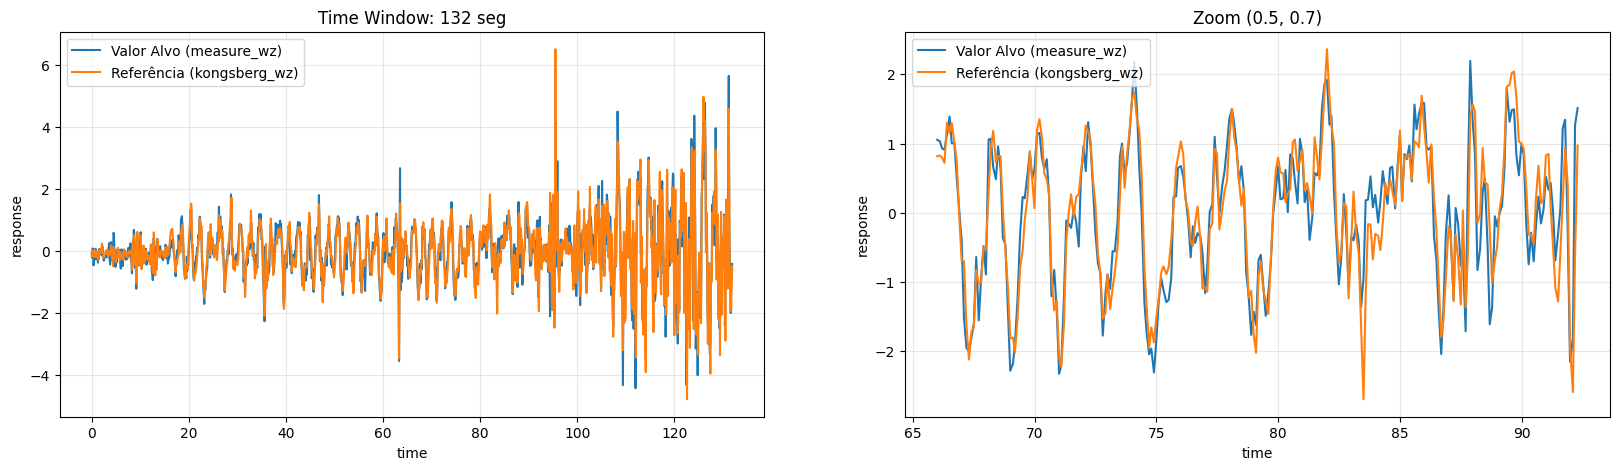

In [505]:
VIEW_TIME = (df.time.values[-1]*VIEW_LIMITS[0], df.time.values[-1]*VIEW_LIMITS[1])
target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, normalize(df[RAW_VAR]), label=f'Valor Alvo ({RAW_VAR})')
plt.plot(df.time, normalize(df[REF_VAR]), label=f'Referência ({REF_VAR})')
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.title(f'Time Window: {df.time.max():.0f} seg')

plt.subplot(1, 2, 2)
plt.plot(target.time, normalize(target[RAW_VAR]), label=f'Valor Alvo ({RAW_VAR})')
plt.plot(target.time, normalize(target[REF_VAR]), label=f'Referência ({REF_VAR})')
plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
plt.title(f'Zoom {VIEW_LIMITS}')
plt.show()

# AMOSTRAGEM

0.1


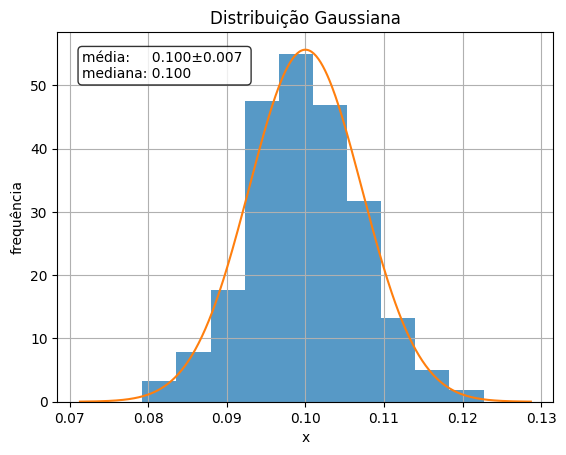

In [506]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


target = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]
time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
print(dt)
gaussian(time)

In [507]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
0,0.0,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.3497,105000000.0,-0.02016,0.15330,-2041,995881,10237,0,414,-42019,542,4006.0,0,44195,0,0,-34458,0.0
1,0.1,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.3400,205000000.0,-0.02187,0.12410,-2049,996410,9993,0,404,16833,542,-25410.0,0,-8122,0,0,-35491,0.0
2,0.2,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.3360,305000000.0,-0.02364,0.10510,-2069,997799,11574,0,405,23077,547,39225.0,0,-8988,0,0,-37327,0.0
3,0.3,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.3610,405000000.0,-0.02549,0.10260,-2080,996266,9130,0,411,9916,544,29310.0,0,-22547,0,0,-38009,0.0
4,0.4,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.3827,505000000.0,-0.02747,0.10320,-2081,994063,8906,0,414,-22535,533,-77711.0,0,-22888,0,0,-37566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,131.5,0.6957,-10.060,0.6976,-0.16650,-0.03909,-2.742176,10.250215,88.636571,-16.913714,-1.242745,-0.126051,0.1927,605000000.0,10.00000,-0.38050,2920,1034084,46592,0,14940,8968820,-1921,-136565.0,0,-807466,0,0,14177,0.0
1316,131.6,0.6957,-10.060,0.6976,-0.16650,-0.03909,-2.742176,10.250215,88.636571,-16.913714,-1.242745,-0.126051,0.1927,605000000.0,10.00000,-0.38050,2920,1034084,46592,0,14940,8968820,-1921,-136565.0,0,-807466,0,0,14177,0.0
1317,131.7,0.6925,-9.779,0.6993,-0.17330,-0.03692,-0.790109,11.023708,88.865754,-17.280407,-4.015861,-0.199561,0.3090,805000000.0,10.00000,-0.05143,2820,985402,50514,0,30550,6105110,-2160,-204711.0,0,413271,0,0,82080,0.0
1318,131.8,0.6921,-9.779,0.6993,-0.17520,-0.03588,-0.543508,11.264350,88.865754,-17.366351,-2.208752,0.274676,0.4736,905000000.0,10.00000,-0.15220,2099,950972,96136,0,35288,3612561,-908,-126821.0,0,1359422,0,0,53686,0.0


# CURVE FIT

In [508]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

In [509]:
class TemporalFit:
    def __init__(self, time, xData, yData, max_iter=2100000000):
        self.time  = np.array(time)
        self.xData = np.array(xData)
        self.yData = np.array(yData)
        self.max_iter = max_iter
        self.coefs = []

    def f(self, x, a, b):
        return a*x + b

    def apply(self, data):
        if len(self.coefs) == 0:
            return None

        return self.f(np.array(data), *self.coefs)
    
    def update(self):
        result      = curve_fit(self.f, self.xData, self.yData, maxfev=self.max_iter)
        self.coefs  = [float(round(coef, 12)) for coef in list(result[0])]
        self.yModel = self.apply(self.xData)
        
        self.error = (self.yData - self.yModel)
        self.rmse  = np.sqrt(np.mean(self.error**2))
        self.mae   = np.mean(np.abs(self.error))
        self.max_error = np.max(np.abs(self.error))

        self.scale_factor_error = np.abs(1.0 - self.coefs[0]) * 100 
        self.std_noise = self.error.std()
        
        ss_res = np.sum(self.error**2) 
        ss_tot = np.sum((self.yData - np.mean(self.yData))**2) 

        if ss_tot == 0:
            self.r2 = 1.0 if ss_res == 0 else 0.0
        else:
            self.r2 = 1 - float(ss_res / ss_tot)

    def plot(self, view_limits=VIEW_LIMITS):
        t_max = self.time[-1]
        
        mask = ((self.time >= t_max * view_limits[0]) & (self.time <= t_max * view_limits[1])) if view_limits else slice(None)
        t_plot   = self.time[mask]
        x_plot   = self.xData[mask]
        y_plot   = self.yData[mask]
        mod_plot = self.yModel[mask]
        err_plot = self.error[mask]
        title = f" (Zoom: {t_max * view_limits[0]:.1f}s a {t_max * view_limits[1]:.1f}s)" if view_limits else ""

        plt.figure(figsize=(20, 10))
        
        plt.subplot(2, 2, 1)
        plt.plot(t_plot, x_plot)
        plt.xlabel('time'); plt.ylabel('response')
        plt.grid(); plt.title('Raw Value' + title)
        
        plt.subplot(2, 2, 2)
        plt.plot(t_plot, y_plot)
        plt.xlabel('time'); plt.ylabel('response')
        plt.grid(); plt.title('Reference Value' + title)

        plt.subplot(2, 2, 3)
        plt.plot(t_plot, y_plot, color='blue', label='reference')
        plt.plot(t_plot, mod_plot, color='red', label='model')
        plt.xlabel('time'); plt.ylabel('response')
        plt.legend(); plt.title(f'R2 Score {self.r2:.3f}')
        plt.grid()

        plt.subplot(2, 2, 4)
        plt.plot(t_plot, err_plot, color='blue')
        plt.xlabel('time'); plt.ylabel('response')
        plt.ylim(-self.max_error*3, self.max_error*3)
        plt.title(f'temporal error (max={self.max_error:.3f} | rmse={self.rmse:.3f})')
        plt.grid(); plt.show()

    def display(self):
        display(pd.DataFrame([{'r2': self.r2, 'mae': self.mae, 'rmse': self.rmse, 'max_error': self.max_error}]))

,r2,mae,rmse,max_error
0,0.802263,0.634826,0.962616,8.207978


Análise de Calibração - measure_wz
Precisão: ±1.9252 m/s² (95% de confiança)
Bias do Sensor:  -0.0194 m/s²
Fator de Escala: 0.0000


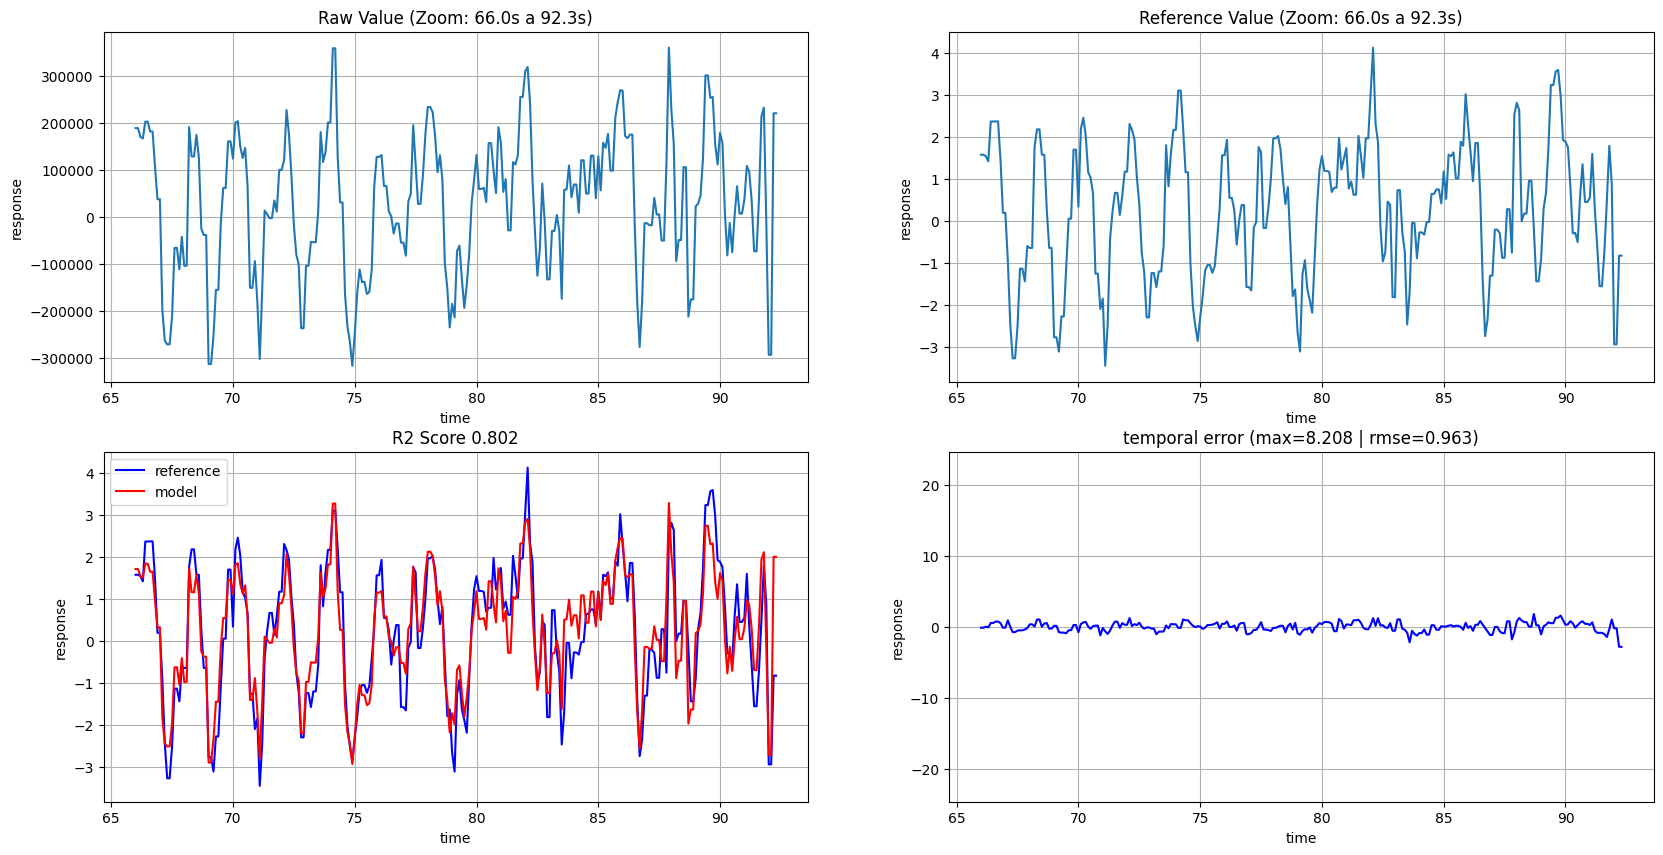

In [510]:
model = TemporalFit(df.time, df[RAW_VAR], df[REF_VAR])
model.update()
model.display()

erro_medio = model.mae
erro_pico  = model.rmse
escala     = model.coefs[0] # Sensibilidade (o 'a' de ax + b)
bias       = model.coefs[1] # Offset (o 'b' de ax + b)
precision  = 2 * model.error.std() # Calculando o intervalo de 95% de confiança

print(f'Análise de Calibração - {RAW_VAR}')
print(f'Precisão: ±{precision:.4f} m/s² (95% de confiança)')
print(f'Bias do Sensor:  {bias:.4f} m/s²')
print(f'Fator de Escala: {escala:.4f}')
model.plot()

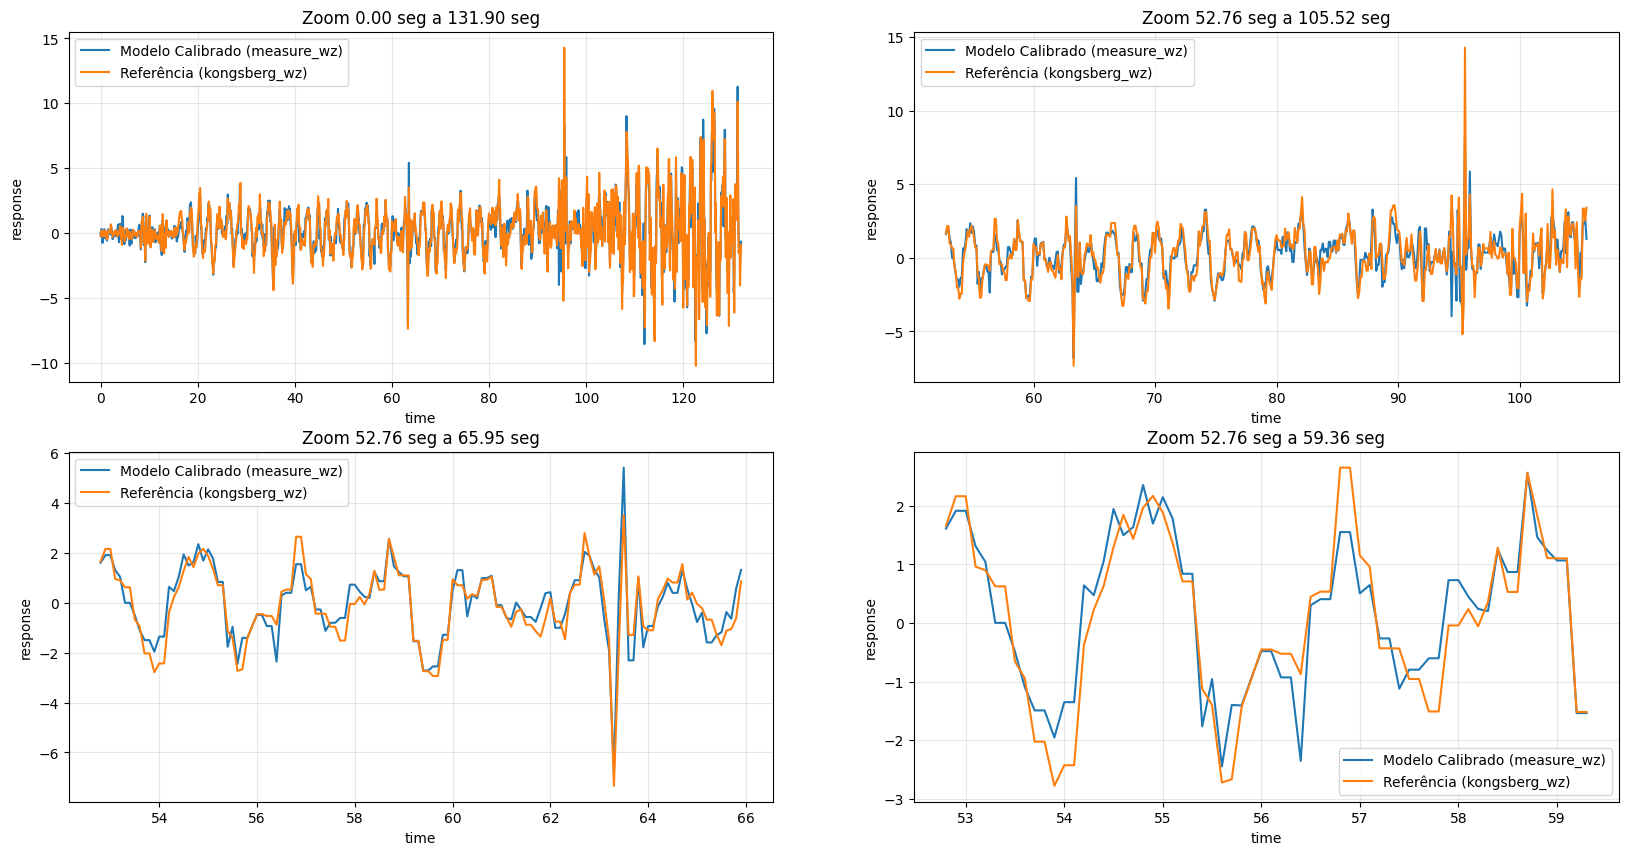

In [511]:
df['model'] = model.apply(df[RAW_VAR])

def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]
    
    plt.plot(target.time, target.model, label=f'Modelo Calibrado ({RAW_VAR})')
    plt.plot(target.time, target[REF_VAR], label=f'Referência ({REF_VAR})')
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(2, 2, 2)
plotViews(df, limits=(0.4, .8))

plt.subplot(2, 2, 3)
plotViews(df, limits=(0.4, .5))

plt.subplot(2, 2, 4)
plotViews(df, limits=(0.4, .45))

plt.show()

In [512]:
import pandas as pd

class Calibration:
    def __init__(self, model_fit, variable_name):
        self.model    = model_fit
        self.var_name = variable_name
        self.max_noise_std       = 0.0
        self.max_scale_error_pct = 0.0
        
    def evaluate(self, value, threshold):
        return "Passed" if value <= threshold else "Failed"

    def get(self):
        df = pd.DataFrame({
            'Test': [
                f'STD sensor noise [{self.var_name}]', 
                f'RMS scale factor error [%]'
            ],
            'Test requirement': [
                self.max_noise_std, 
                self.max_scale_error_pct
            ],
            'Value Measured': [
                round(self.model.std_noise, 4),
                round(self.model.scale_factor_error, 4)
            ],
            'Status': [
                self.evaluate(self.model.std_noise, self.max_noise_std),
                self.evaluate(self.model.scale_factor_error, self.max_scale_error_pct)
            ]
        })
        
        df.set_index('Test', inplace=True)
        return df



calibration = Calibration(model, RAW_VAR)
calibration.max_noise_std       = 0.05
calibration.max_scale_error_pct = 0.10
calibration.get()

,Test requirement,Value Measured,Status
Test,,,
STD sensor noise [measure_wz],0.05,0.9626,Failed
RMS scale factor error [%],0.10,99.9991,Failed


# GERANDO RELATÓRIO

In [513]:
import os
import io
import json

PURPLE_MID  = '#6A3CBC'
PINK_ACCENT = '#E91E63'

class ResultExporter:
    def __init__(self, basePath, rawVar, model, calibration=None):
        self.basePath = basePath
        self.rawVar = rawVar
        self.model = model
        self.calibration = calibration
        self.outputDir = os.path.join(basePath, 'release', rawVar)

    def _ensureDir(self):
        os.makedirs(self.outputDir, exist_ok=True)

    def _makePlot(self, plotType, width=250, height=150):
        fig, ax = plt.subplots(figsize=(width / 72, height / 72), dpi=150)
        model = self.model
        label = self.rawVar.capitalize()

        if plotType == 'ref':
            ax.plot(model.time, model.yData, color=PURPLE_MID, linewidth=0.8, label='Referência')
            ax.plot(model.time, model.yModel, color=PINK_ACCENT, linewidth=0.8, label='Medido')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Ângulo (deg)', fontsize=7)
            ax.set_title(f'{label}: Referência vs. Medido', fontsize=8, fontweight='bold')
        else:
            ax.plot(model.time, model.error, color=PURPLE_MID, linewidth=0.8, label='Erro')
            ax.legend(fontsize=6, loc='upper right')
            ax.set_ylabel('Erro (deg)', fontsize=7)
            ax.set_ylim(-max(model.error*3.5), max(model.error*3.5))
            ax.set_title(f'Erro Temporal – {label}', fontsize=8, fontweight='bold')

        ax.set_xlabel('Tempo (s)', fontsize=7)
        ax.tick_params(axis='both', labelsize=6)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        plt.tight_layout(pad=0.5)
        return fig

    def exportPlots(self):
        self._ensureDir()

        figRef = self._makePlot('ref')
        refPath = os.path.join(self.outputDir, 'ref_vs_model.png')
        figRef.savefig(refPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figRef)

        figErr = self._makePlot('error')
        errPath = os.path.join(self.outputDir, 'error.png')
        figErr.savefig(errPath, format='png', dpi=150, bbox_inches='tight')
        plt.close(figErr)

        return refPath, errPath

    def exportMetrics(self):
        self._ensureDir()
        model = self.model

        precision = 2 * model.error.std()

        metrics = {
            'r2': float(round(model.r2, 6)),
            'mae': float(round(model.mae, 6)),
            'rmse': float(round(model.rmse, 6)),
            'maxError': float(round(model.max_error, 6)),
            'scaleFactorError': float(round(model.scale_factor_error, 6)),
            'stdNoise': float(round(model.std_noise, 6)),
            'coefs': [float(c) for c in model.coefs],
            'precision': float(round(precision, 6)),
        }

        path = os.path.join(self.outputDir, 'metrics.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(metrics, f, indent=2, ensure_ascii=False)

        return path

    def exportCalibration(self):
        self._ensureDir()
        if self.calibration is None:
            return None

        calDf = self.calibration.get()
        tests = []
        for idx, row in calDf.iterrows():
            tests.append({
                'name': str(idx),
                'requirement': float(row['Test requirement']),
                'measured': float(row['Value Measured']),
                'status': str(row['Status']),
            })

        data = {'tests': tests}
        path = os.path.join(self.outputDir, 'calibration.json')
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)

        return path

    def export(self):

        matplotlib.use('Agg')
        self._ensureDir()
        refPath, errPath = self.exportPlots()
        metricsPath = self.exportMetrics()
        calPath = self.exportCalibration()

        print(f'[export] Resultados exportados para: {self.outputDir}')
        print(f'  → {refPath}')
        print(f'  → {errPath}')
        print(f'  → {metricsPath}')
        if calPath:
            print(f'  → {calPath}')

        return self.outputDir


GENERATE_REPORT = False
RAW_VAR = 'roll'
exporter = ResultExporter('.', RAW_VAR, model)

if GENERATE_REPORT:
    exporter.export()